https://github.com/aeon-toolkit/aeon/blob/main/examples/anomaly_detection/anomaly_detection.ipynb



https://www.sktime.net/en/v0.34.0/examples/07_detection_anomaly_changepoints.html

https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/anomalydetection.html

https://github.com/GeneSUN/Anomaly_Detection_toolkit

https://forecastegy.com/posts/time-series-anomaly-detection-python/

#### Импорт

#### Утилиты 

##### Скачивем, если их нет

In [32]:
import os
if not os.path.exists('utilits4tsc'):
    !git clone --depth 1 https://github.com/MVRonkin/TimeSeriesCourse.git temp_repo
    !mv temp_repo/2026/WS/utilits4tsc .

##### содержание

In [33]:
from utilits4tsc import *
plt_style_GOST()
from IPython.display import display, Markdown
display(Markdown(generate_toc(max_lvl=2)))

## Содержание
  * [Обнаружение нерегулярного поведения в данных](#обнаружение-нерегулярного-поведения-в-данных)

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [35]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [36]:
from scipy import stats
# import pmdarima as pm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.stattools import kpss
import statsmodels.api as sm

In [37]:
from pandas.tseries.frequencies import to_offset

In [38]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter("ignore", FutureWarning)

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [39]:
from functools import partial

### Загрузка данных

Импорт данных аналогично предыдущего урока.

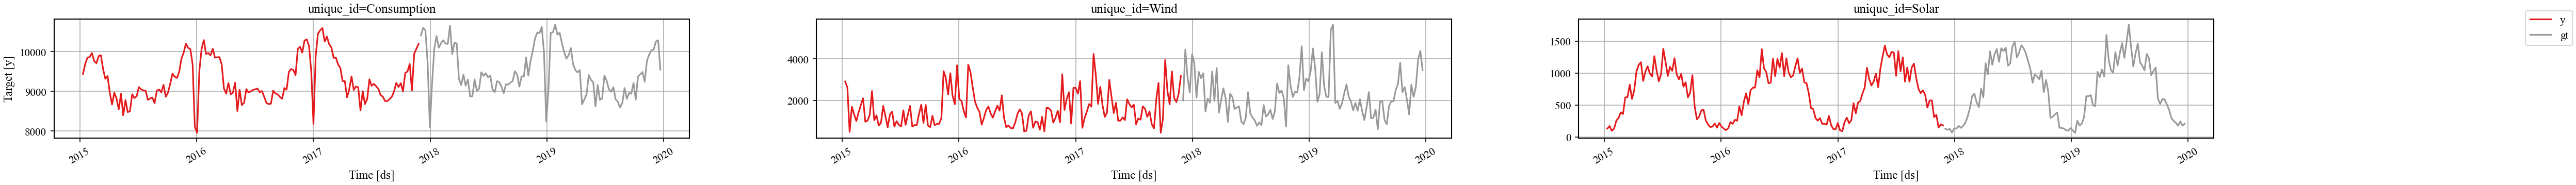

In [40]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series_v2(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1', n_cols = 3)

In [41]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'mae': mae,
    'rmse': rmse,
    'smape': smape,
    'CPSR':scaled_crps,
    'CI':coverage,
    'SQL':partial(scaled_quantile_loss, seasonality=SEASON),
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

## Обнаружение нерегулярного поведения в данных

### Использование вероятностного предсказания для поиска аномалий

Here we identified the anomalies in the data using the MSTL model, but any probabilistic model from StatsForecast can be used. We also selected the 99% prediction interval of the insample forecasts, but other confidence levels can be used as well.

In [42]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL

#### выбор уровня доверия к данным 

In [ ]:
levels = [99]

#### Выбор модели

In [ ]:
models = [MSTL(season_length=[SEASON], alias='MSTL')]
alias = [x.alias for x in models]

#### Обучение модели  in-sample prediction

In [ ]:
sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst = sf.forecast(df=df_train, h=FH, level=levels, fitted=True)

insample_forecasts = sf.forecast_fitted_values().drop(columns=['y'])

res_df = panel_df.merge(pd.concat([insample_forecasts,fcst],), on=['unique_id', 'ds'], how='left')


#### Выбор и визуализация аномалий
##### Встроенная визуализация аномалий по интервалу перекрытия

In [ ]:
plot_series_v2(forecasts_df=res_df, level=levels, plot_anomalies=True)

##### Визуализация заданных аномалий

In [ ]:
anomalies = res_df[~res_df['y'].between(res_df['MSTL-lo-99'], res_df['MSTL-hi-99'])][['unique_id', 'ds', 'y']].copy()
anomalies['MSTL_anomaly'] = 1
anomalies.head(2)

In [ ]:
res_df['residual'] = res_df['y'] - res_df['MSTL']


In [ ]:
plot_series_v2(
    forecasts_df=res_df,
    level=levels,
    models=alias,
    anomalies_df=anomalies,
    marker_size=10,
    anomaly_width='1w',
    second_axis = 'residual'
)

Проведем оценку числа аномалий, в идеале для откалиброванного 1% интервала число точек в нем должно быть порядка 1%.

In [ ]:
res_df['is_anomaly'] = ~res_df['y'].between(res_df['MSTL-lo-99'], res_df['MSTL-hi-99'])

calibration = 100*res_df.groupby('unique_id')['is_anomaly'].mean()
calibration

Также на графике видно, что остатки предсказания имеют наибольшее значение на аномалиях (что и ожидаемо, однако, остатков по аномалиям было бы больше)

### Аномаии по Z robust score  остатков


In [ ]:
res_df['residual'] = res_df['y'] - res_df['MSTL']

def mad_anomaly(x, k=3):
    median = np.median(x)
    mad = 1.4826 * np.median(np.abs(x - median))
    score = np.abs(x - median) / (mad + 1e-8)
    return (score > k).astype(int)

res_df['anomaly'] = res_df.groupby('unique_id')['residual'].transform(mad_anomaly)

In [ ]:
anomalies = res_df[res_df['anomaly'] >0][['unique_id', 'ds', 'y']].copy()

In [ ]:

plot_series_v2(
    forecasts_df=res_df,
    level=levels,
    models=alias,
    anomalies_df=anomalies,
    marker_size=10,
    anomaly_width='1w',
    second_axis = 'residual'
)

В иделае медиану и MAD нужно считать на участке без аномалий

### Гистограмма с подсветкой аномалий

In [ ]:
for uid, df_uid in res_df.groupby('unique_id'):
    plt.figure()
    
    # нормальные точки
    plt.hist(df_uid[df_uid['anomaly']==0]['residual'], bins=50, alpha=0.6, label='normal')
    
    # аномалии
    plt.hist(df_uid[df_uid['anomaly']==1]['residual'], bins=50, alpha=0.6, label='anomaly')
    
    plt.title(f"Residual distribution: {uid}")
    plt.legend()
    plt.show()

На гистограмме:

аномалии в хвостах → ✔ нормальное поведение

аномалии в центре → ❗ модель плохая

асимметрия (только справа/слева) → разные типы аномалий

In [ ]:
from statsmodels.tsa.stattools import acf

acf_compare = []

for uid, df_uid in res_df.groupby('unique_id'):
    
    full_acf = acf(df_uid['residual'].dropna(), nlags=10)
    clean_acf = acf(df_uid[df_uid['anomaly']==0]['residual'].dropna(), nlags=10)
    
    acf_compare.append(pd.DataFrame({
        'lag': range(len(full_acf)),
        'acf_full': full_acf,
        'acf_clean': clean_acf,
        'unique_id': uid
    }))

acf_compare_df = pd.concat(acf_compare)
acf_compare_df.head()

если acf_clean << acf_full
→ аномалии создают зависимость

если одинаково
→ проблема в модели, не в выбросах

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_test(x):
    return acorr_ljungbox(x, lags=[10], return_df=True)['lb_pvalue'].iloc[0]

lb_results = []

for uid, df_uid in res_df.groupby('unique_id'):
    
    p_full = ljung_test(df_uid['residual'].dropna())
    p_clean = ljung_test(df_uid[df_uid['anomaly']==0]['residual'].dropna())
    
    lb_results.append({
        'unique_id': uid,
        'p_full': p_full,
        'p_clean': p_clean
    })

lb_df = pd.DataFrame(lb_results)
lb_df

p_full < 0.05, p_clean > 0.05
→ ❗ зависимость вызвана аномалиями

оба < 0.05
→ ❗ модель не описала структуру

оба > 0.05
→ ✔ остатки ≈ белый шум

In [ ]:
from statsmodels.stats.diagnostic import het_arch

def arch_test(x):
    stat, p, _, _ = het_arch(x)
    return p

arch_results = []

for uid, df_uid in res_df.groupby('unique_id'):
    
    p_full = arch_test(df_uid['residual'].dropna())
    p_clean = arch_test(df_uid[df_uid['anomaly']==0]['residual'].dropna())
    
    arch_results.append({
        'unique_id': uid,
        'arch_p_full': p_full,
        'arch_p_clean': p_clean
    })

arch_df = pd.DataFrame(arch_results)
arch_df

p_full < 0.05, p_clean > 0.05
→ аномалии создают волатильность

оба < 0.05
→ модель не учитывает changing variance

In [ ]:
from scipy.stats import genpareto

def evt_threshold(x, q=0.95):
    x = x.dropna()
    threshold = np.quantile(x, q)
    excess = x[x > threshold] - threshold
    
    if len(excess) < 5:
        return np.nan
    
    params = genpareto.fit(excess)
    return threshold + genpareto.ppf(0.99, *params)

evt_thr = res_df.groupby('unique_id')['residual'].apply(evt_threshold)

res_df = res_df.join(evt_thr.rename('evt_thr'), on='unique_id')

res_df['evt_anomaly'] = (res_df['residual'] > res_df['evt_thr']).astype(int)


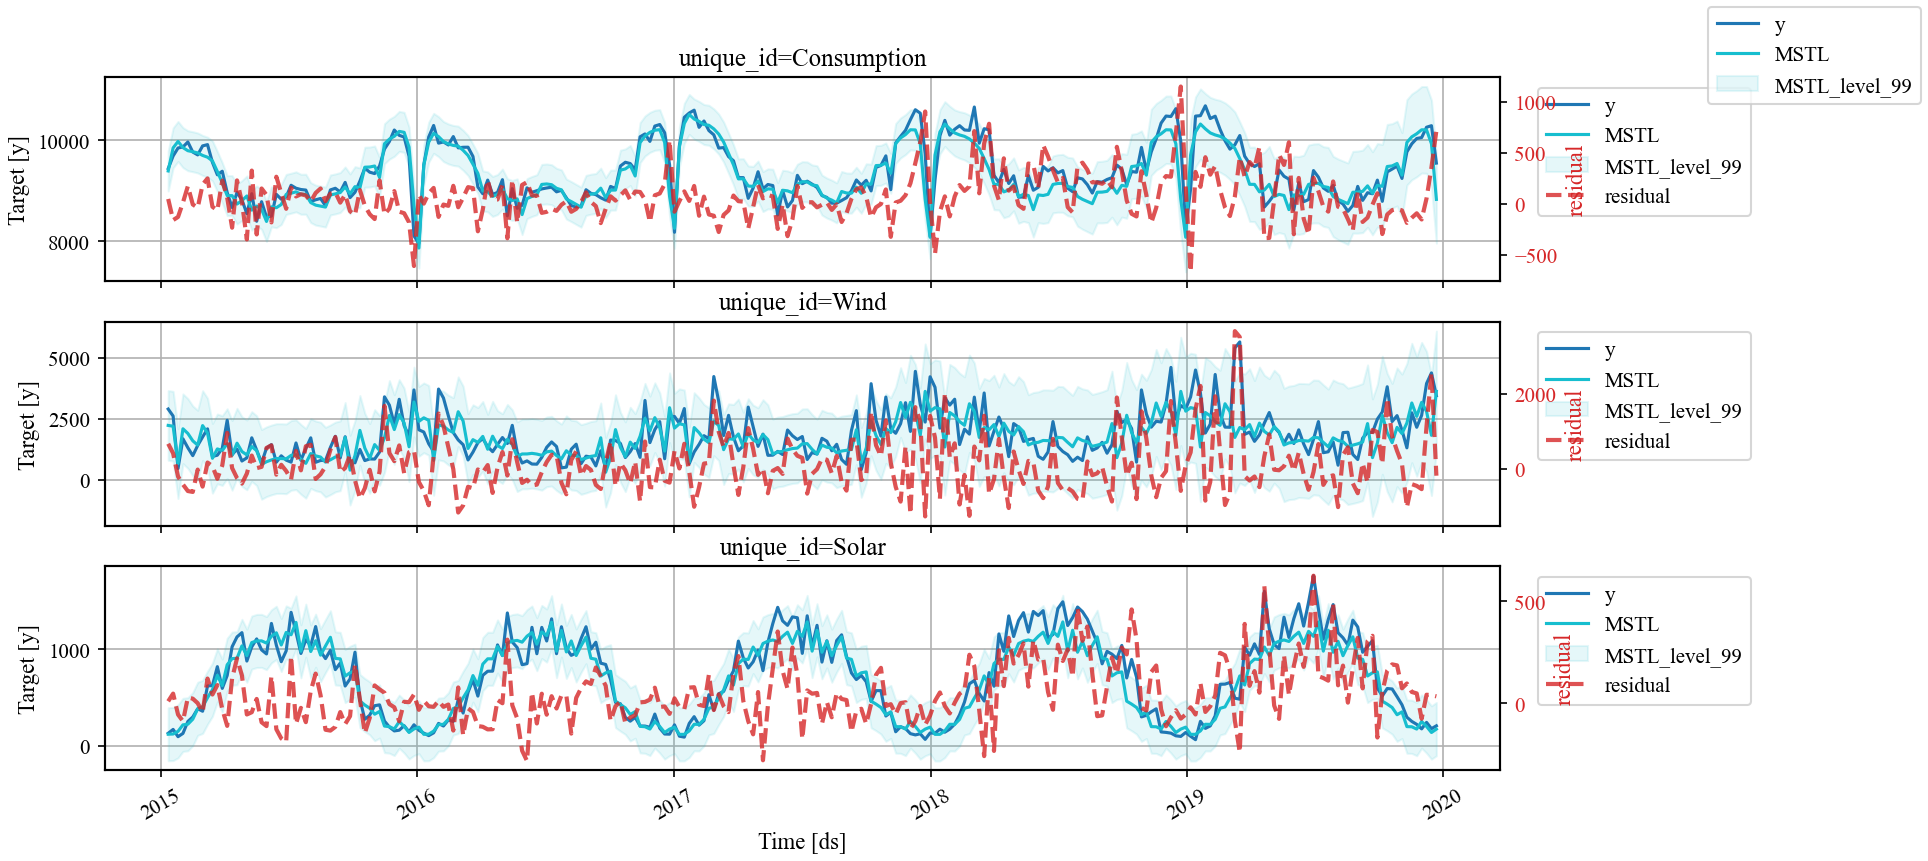

In [30]:
anomalies = res_df[res_df['evt_anomaly'] >0][['unique_id', 'ds', 'y']].copy()
plot_series_v2(
    forecasts_df=res_df,
    level=levels,
    models=alias,
    anomalies_df=anomalies,
    marker_size=10,
    anomaly_width='1w',
    second_axis = 'residual'
)

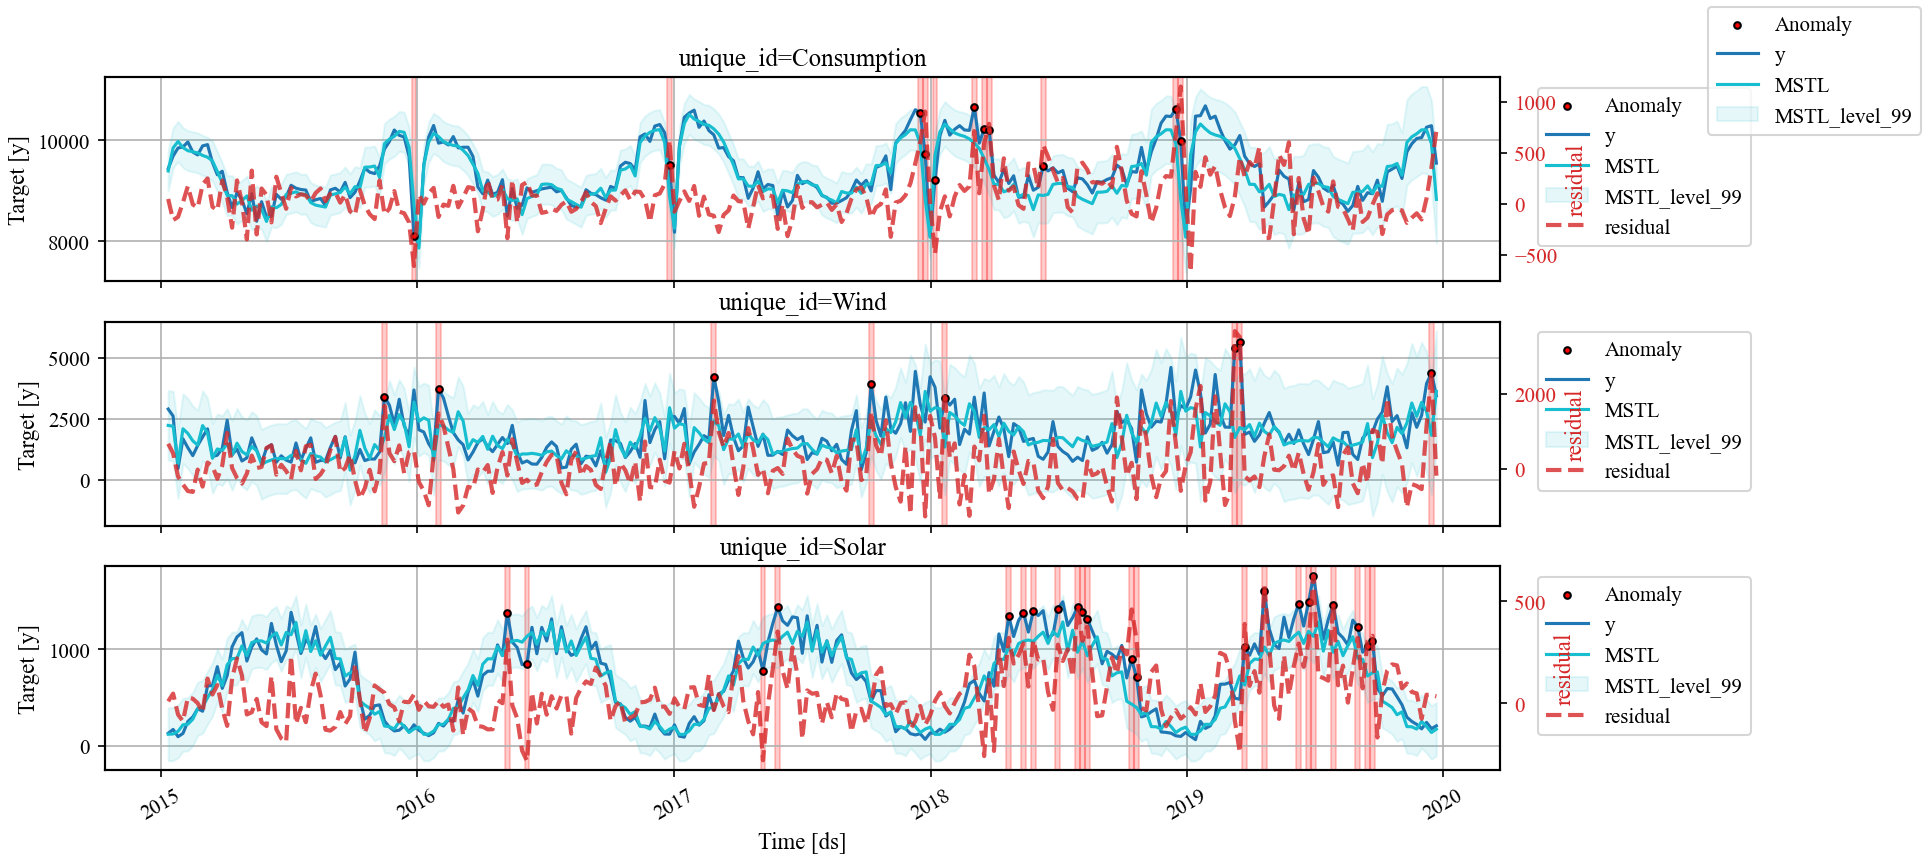

In [58]:
import numpy as np

res_df.groupby('unique_id')['residual'].agg(
    median='median',
    mad=lambda x: 1.4826 * np.median(np.abs(x - np.median(x)))
)
anomalies = res_df[~res_df['y'].between(res_df['MSTL-lo-99'], res_df['MSTL-hi-99'])][['unique_id', 'ds', 'y']].copy()
anomalies['MSTL_anomaly'] = 1

plot_series_v2(
    forecasts_df=res_df,
    level=levels,
    models=alias,
    anomalies_df=anomalies,
    marker_size=10,
    anomaly_width='1w',
    second_axis = 'residual'
)

In [ ]:
def mark_edges(df, frac=0.1):
    n = len(df)
    k = int(n * frac)
    
    df = df.sort_values('ds').copy()
    df['is_edge'] = 0
    df.iloc[:k, df.columns.get_loc('is_edge')] = 1
    df.iloc[-k:, df.columns.get_loc('is_edge')] = 1
    
    return df

res_df = res_df.groupby('unique_id', group_keys=False).apply(mark_edges)

edge_analysis = res_df.groupby(['unique_id', 'is_edge'])['MSTL_anomaly'].mean().unstack()
edge_analysis.columns = ['middle', 'edges']

edge_analysis

In [ ]:
from mlforecast import MLForecast
from lightgbm import LGBMRegressor

lags = [1, 2, 3, 7, 14, 28, 52]

fcst = MLForecast(
    models=[LGBMRegressor(n_estimators=200, random_state=42)],
    freq=FREQ,
    lags=lags,
    date_features=['weekofyear', 'month']
)

fcst.fit(df_train_ml)

In [ ]:
ml_preds = fcst.predict(h=FH)

ml_preds = ml_preds.rename(columns={'LGBMRegressor': 'y_hat'})

In [ ]:
ml_res = df_test_ml.merge(ml_preds, on=['unique_id', 'ds'])

ml_res['residual'] = ml_res['y'] - ml_res['y_hat']

In [ ]:
def detect_anomalies(x, k=3):
    median = x.median()
    mad = 1.4826 * np.median(np.abs(x - median))
    
    score = np.abs(x - median) / (mad + 1e-8)
    return (score > k).astype(int)

ml_res['ml_anomaly'] = ml_res.groupby('unique_id')['residual'].transform(detect_anomalies)

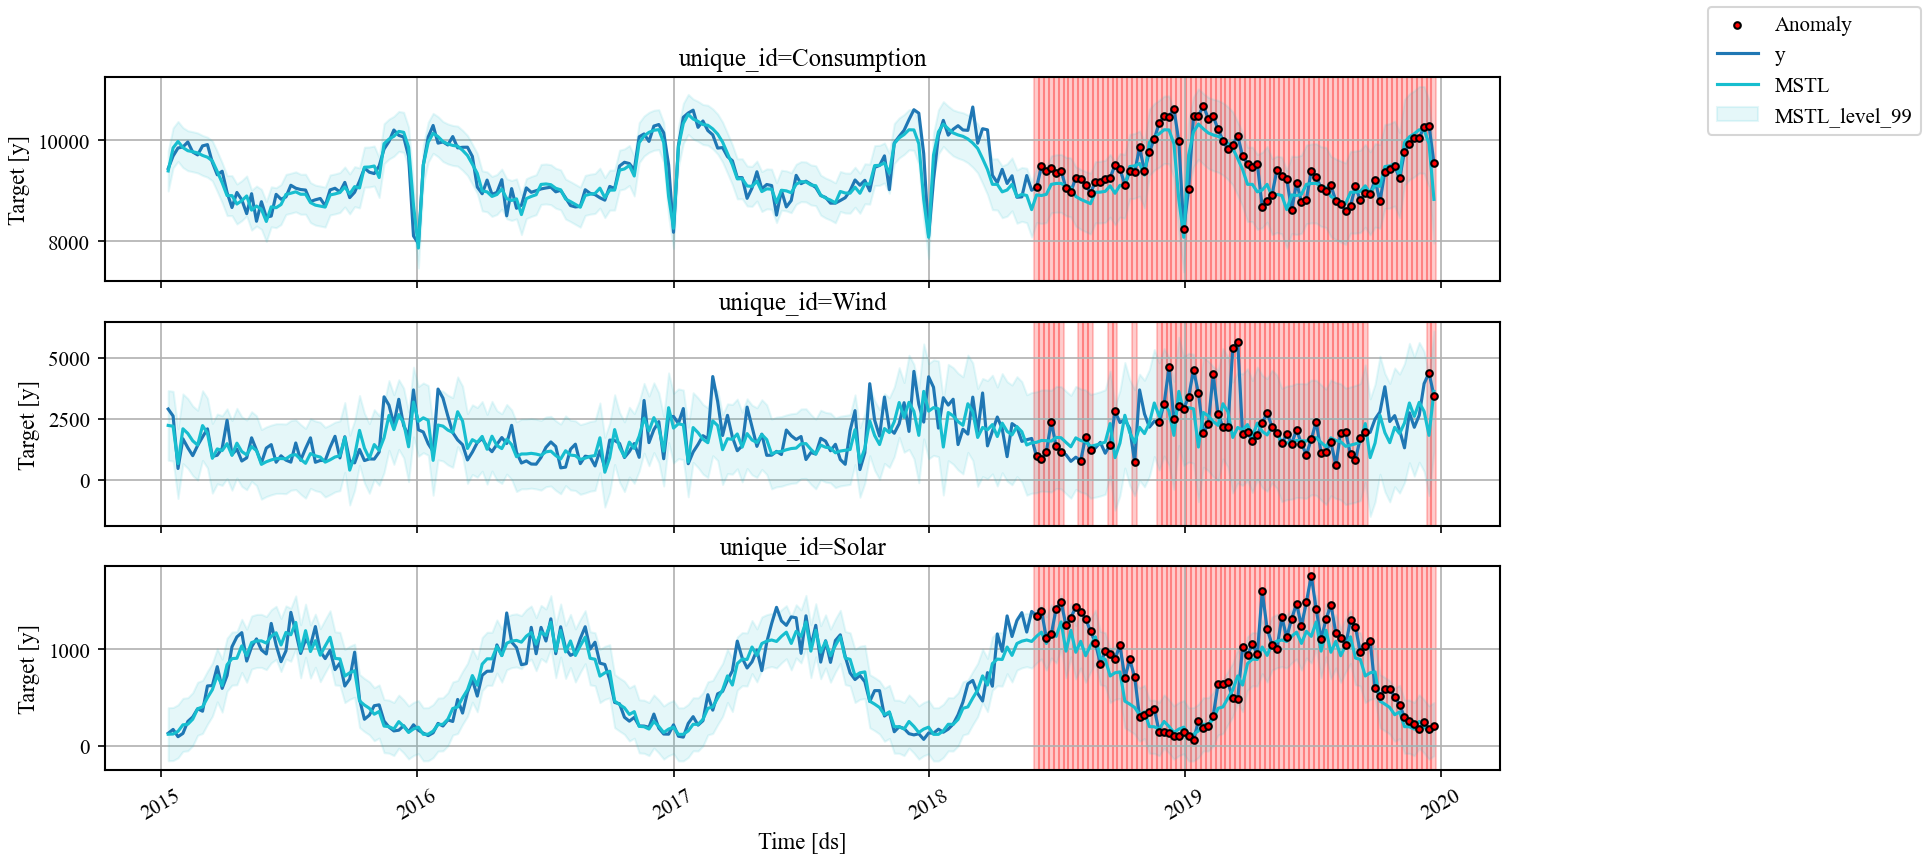

In [31]:
from scipy.stats import ks_2samp
from hmmlearn.hmm import GaussianHMM

# ══════════════════════════════════════════════
# 1. ДРЕЙФ ДАННЫХ — скользящее окно по остаткам
#    train задаёт референс, проверяем каждое окно
# ══════════════════════════════════════════════

DRIFT_WINDOW   = 26    # размер окна (недель)
DRIFT_PVAL     = 0.05  # порог значимости KS-теста
DRIFT_MEAN_STD = 1.5   # порог mean shift (в сигмах train)
DRIFT_VAR_RATIO= 2.0   # порог variance shift (ratio)

def detect_drift(res_df, window=DRIFT_WINDOW,
                 pval=DRIFT_PVAL,
                 mean_thr=DRIFT_MEAN_STD,
                 var_thr=DRIFT_VAR_RATIO):
    records = []
    for uid, grp in res_df.groupby('unique_id'):
        grp = grp.sort_values('ds').reset_index(drop=True)

        train_res = grp.loc[grp['is_train'], 'residual']
        ref_mu    = train_res.mean()
        ref_sigma = train_res.std() + 1e-8
        ref_var   = train_res.var() + 1e-8

        # только в test части
        test_grp = grp[~grp['is_train']].reset_index(drop=True)

        for i in range(window, len(test_grp)):
            window_res = test_grp.loc[i-window:i, 'residual']

            # Mean shift
            mean_shift = abs(window_res.mean() - ref_mu) / ref_sigma

            # Variance shift
            var_ratio  = window_res.var() / ref_var

            # Distribution shift (KS)
            _, ks_pval = ks_2samp(train_res.values, window_res.values)

            drift_flag = (
                (mean_shift > mean_thr) or
                (var_ratio  > var_thr)  or
                (ks_pval    < pval)
            )

            if drift_flag:
                row = test_grp.iloc[i]
                records.append({
                    'unique_id':  uid,
                    'ds':         row['ds'],
                    'y':          row['y'],
                    'mean_shift': round(mean_shift, 3),
                    'var_ratio':  round(var_ratio,  3),
                    'ks_pval':    round(ks_pval,    4),
                })

    return (pd.DataFrame(records)
              .drop_duplicates(subset=['unique_id', 'ds'])
              .reset_index(drop=True))

drift_df = detect_drift(res_df)
 


# ══════════════════════════════════════════════
# ПЛОТЫ
# ══════════════════════════════════════════════

# 1. Дрейф данных
plot_series_v2(
    forecasts_df=res_df,
    level=levels,
    models=['MSTL'],
    anomalies_df=drift_df[['unique_id', 'ds', 'y']],
    marker_size=10,
    anomaly_width='1w'
)



Смен режима: 262
unique_id
Consumption    86
Solar          87
Wind           89
Name: n_transitions, dtype: int64


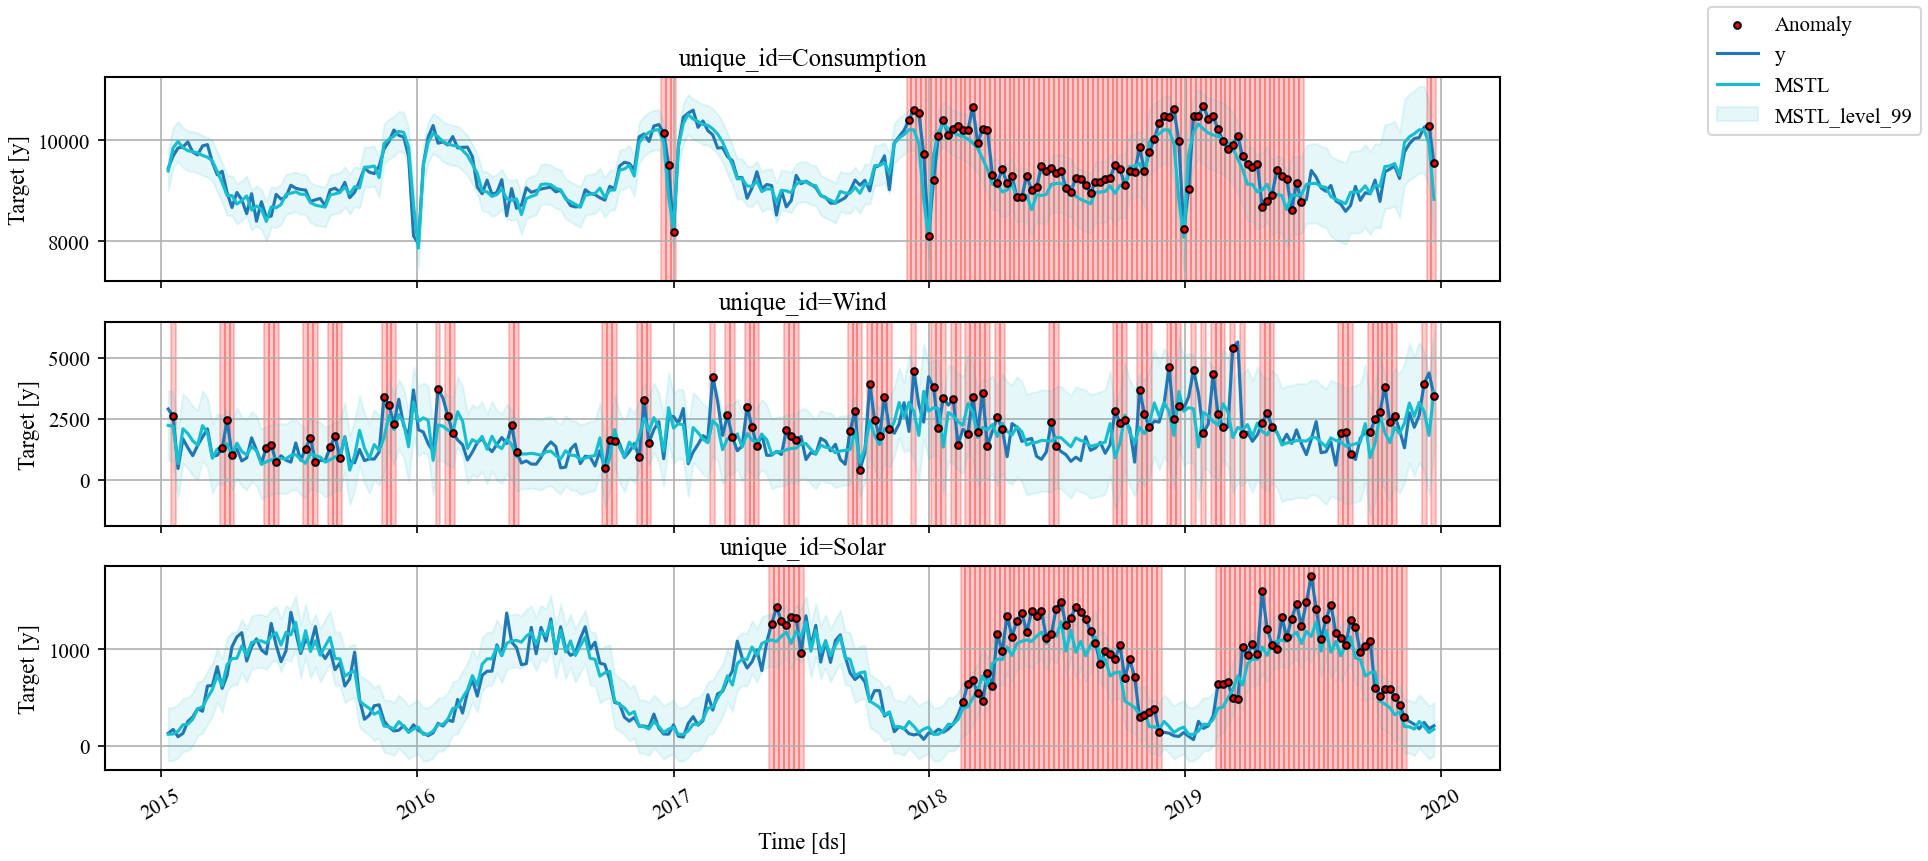

In [32]:
# ══════════════════════════════════════════════
# 2. СЕГМЕНТАЦИЯ ВР — HMM по остаткам
#    → колонка hmm_regime в res_df
#    → transitions_df — точки смены режима для плота
# ══════════════════════════════════════════════

N_STATES = 3   # low / medium / high режим

def segment_hmm(res_df, n_states=N_STATES):
    res_df = res_df.copy()
    res_df['hmm_regime'] = np.nan

    for uid, grp in res_df.groupby('unique_id'):
        grp = grp.sort_values('ds')
        X   = grp[['residual']].fillna(0).values

        model = GaussianHMM(
            n_components=n_states,
            covariance_type='full',
            n_iter=200,
            random_state=42
        )
        model.fit(X)
        labels = model.predict(X)

        # сортируем лейблы по средней величине residual (low=0, high=N-1)
        means  = [X[labels == k].mean() for k in range(n_states)]
        order  = np.argsort(means)
        remap  = {old: new for new, old in enumerate(order)}
        labels = np.array([remap[l] for l in labels])

        res_df.loc[grp.index, 'hmm_regime'] = labels

    res_df['hmm_regime'] = res_df['hmm_regime'].astype(int)
    return res_df

res_df = segment_hmm(res_df)

# Точки смены режима → anomalies_df формат для плота
def regime_transitions(res_df):
    records = []
    for uid, grp in res_df.groupby('unique_id'):
        grp     = grp.sort_values('ds').reset_index(drop=True)
        shifted = grp['hmm_regime'].shift(1)
        mask    = (grp['hmm_regime'] != shifted) & (shifted.notna())
        for _, row in grp[mask].iterrows():
            records.append({'unique_id': uid, 'ds': row['ds'], 'y': row['y']})
    return pd.DataFrame(records)

transitions_df = regime_transitions(res_df)
print(f"\nСмен режима: {len(transitions_df)}")
print(transitions_df.groupby('unique_id').size().rename('n_transitions'))

# 2. Смены режимов HMM
plot_series_v2(
    forecasts_df=res_df,
    level=levels,
    models=['MSTL'],
    anomalies_df=transitions_df,
    marker_size=10,
    anomaly_width='1w'
)

 

Точек дрейфа: 221
unique_id
Consumption    82
Solar          82
Wind           57
Name: n_drift, dtype: int64

Смен режима: 262
unique_id
Consumption    86
Solar          87
Wind           89
Name: n_transitions, dtype: int64


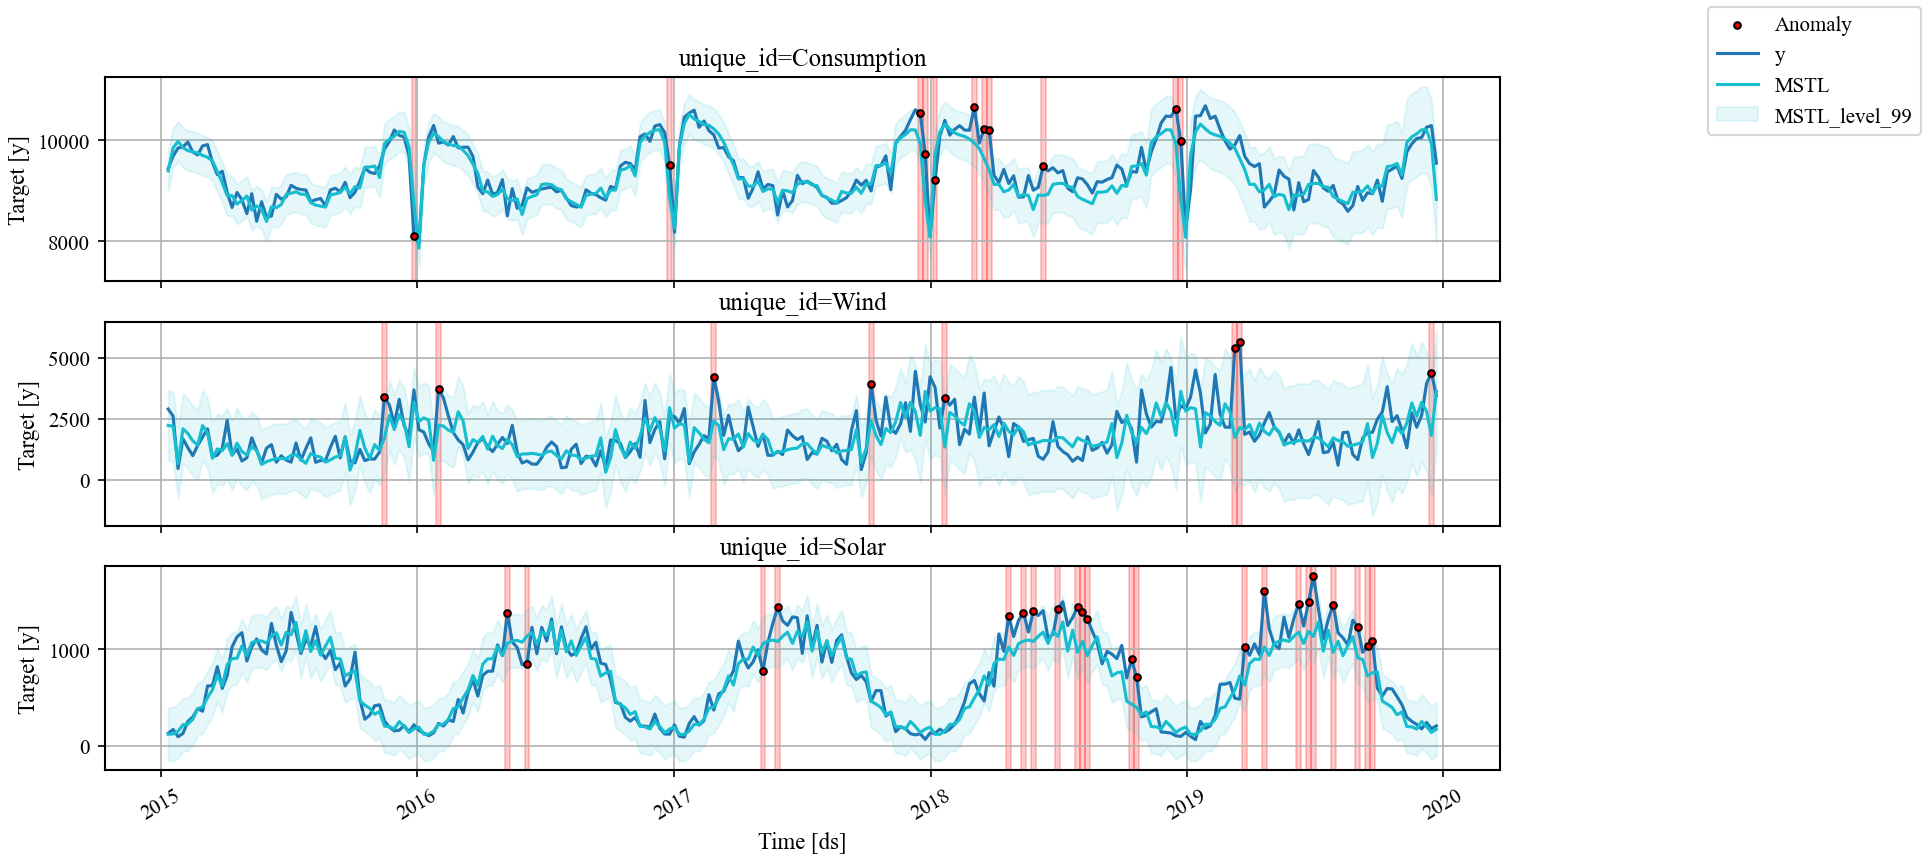

In [34]:
from scipy.stats import ks_2samp
from hmmlearn.hmm import GaussianHMM

# ══════════════════════════════════════════════
# 1. ДРЕЙФ ДАННЫХ
# ══════════════════════════════════════════════
DRIFT_WINDOW    = 26    # недель
DRIFT_PVAL      = 0.05  # KS-тест
DRIFT_MEAN_STD  = 1.5   # mean shift в сигмах
DRIFT_VAR_RATIO = 2.0   # variance ratio

def detect_drift(res_df, window=DRIFT_WINDOW,
                 pval=DRIFT_PVAL,
                 mean_thr=DRIFT_MEAN_STD,
                 var_thr=DRIFT_VAR_RATIO):
    records = []
    for uid, grp in res_df.groupby('unique_id'):
        grp = grp.sort_values('ds').reset_index(drop=True)

        train_res = grp.loc[grp['is_train'], 'residual']
        ref_mu    = train_res.mean()
        ref_sigma = train_res.std()  + 1e-8
        ref_var   = train_res.var()  + 1e-8

        test_grp  = grp[~grp['is_train']].reset_index(drop=True)

        for i in range(window, len(test_grp)):
            win = test_grp.loc[i - window:i, 'residual']

            mean_shift = abs(win.mean() - ref_mu) / ref_sigma
            var_ratio  = win.var() / ref_var
            _, ks_pval = ks_2samp(train_res.values, win.values)

            if (mean_shift > mean_thr) or (var_ratio > var_thr) or (ks_pval < pval):
                row = test_grp.iloc[i]
                records.append({
                    'unique_id':  uid,
                    'ds':         row['ds'],
                    'y':          row['y'],
                    'mean_shift': round(mean_shift, 3),
                    'var_ratio':  round(var_ratio,  3),
                    'ks_pval':    round(ks_pval,    4),
                })

    return (pd.DataFrame(records)
              .drop_duplicates(subset=['unique_id', 'ds'])
              .reset_index(drop=True))

drift_df = detect_drift(res_df)
print(f"Точек дрейфа: {len(drift_df)}")
print(drift_df.groupby('unique_id').size().rename('n_drift'))

# ══════════════════════════════════════════════
# 2. СЕГМЕНТАЦИЯ — HMM
#    regime 0 = низкий, 1 = средний, 2 = высокий
# ══════════════════════════════════════════════
N_STATES = 3

def segment_hmm(res_df, n_states=N_STATES):
    res_df = res_df.copy()
    res_df['hmm_regime'] = np.nan
    for uid, grp in res_df.groupby('unique_id'):
        grp = grp.sort_values('ds')
        X   = grp[['residual']].fillna(0).values
        model = GaussianHMM(n_components=n_states,
                            covariance_type='full',
                            n_iter=200, random_state=42)
        model.fit(X)
        labels = model.predict(X)
        # сортируем: 0=низкий ... N-1=высокий
        means  = [X[labels == k].mean() for k in range(n_states)]
        remap  = {old: new for new, old in enumerate(np.argsort(means))}
        labels = np.array([remap[l] for l in labels])
        res_df.loc[grp.index, 'hmm_regime'] = labels
    res_df['hmm_regime'] = res_df['hmm_regime'].astype(int)
    return res_df

res_df = segment_hmm(res_df)

# точки смены режима → формат anomalies_df
def regime_transitions(res_df):
    records = []
    for uid, grp in res_df.groupby('unique_id'):
        grp     = grp.sort_values('ds').reset_index(drop=True)
        shifted = grp['hmm_regime'].shift(1)
        mask    = (grp['hmm_regime'] != shifted) & shifted.notna()
        for _, row in grp[mask].iterrows():
            records.append({'unique_id': uid, 'ds': row['ds'], 'y': row['y']})
    return pd.DataFrame(records)

transitions_df = regime_transitions(res_df)
print(f"\nСмен режима: {len(transitions_df)}")
print(transitions_df.groupby('unique_id').size().rename('n_transitions'))

# ══════════════════════════════════════════════
# ПЛОТЫ
# ══════════════════════════════════════════════

# 1. Аномалии (CI)
anomalies = res_df[
    ~res_df['y'].between(res_df['MSTL-lo-99'], res_df['MSTL-hi-99'])
][['unique_id', 'ds', 'y']].copy()

plot_series_v2(forecasts_df=res_df, level=levels, models=['MSTL'],
               anomalies_df=anomalies, marker_size=10, anomaly_width='1w')



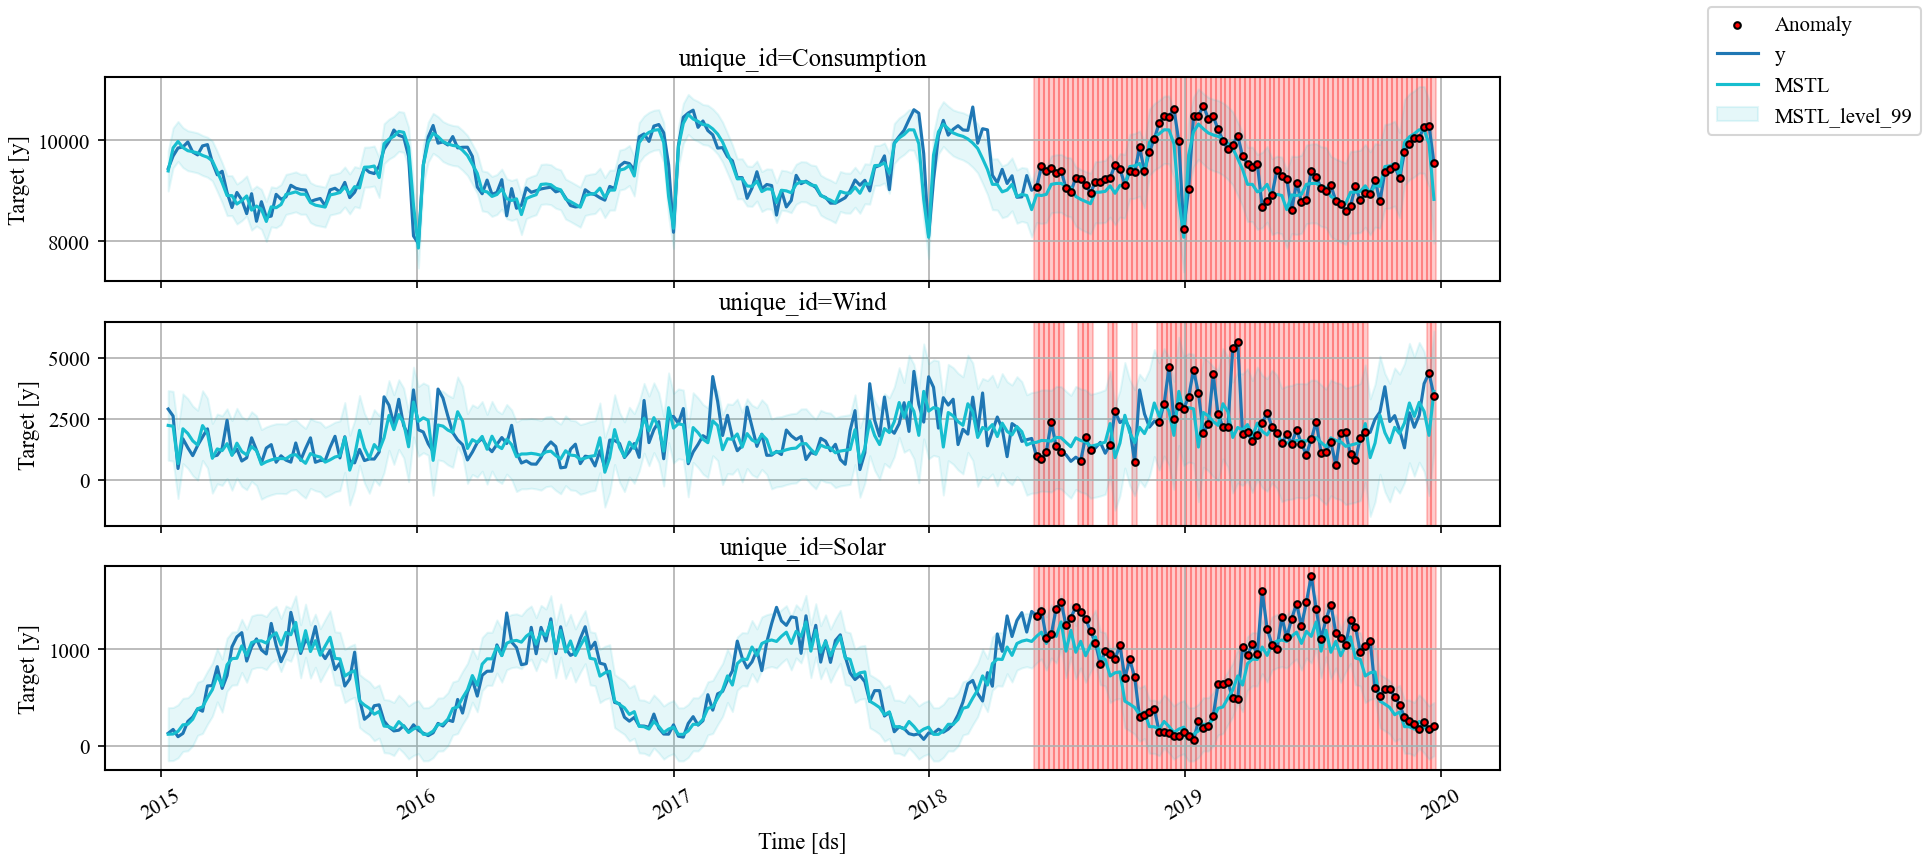

In [35]:
# 2. Дрейф
plot_series_v2(forecasts_df=res_df, level=levels, models=['MSTL'],
               anomalies_df=drift_df[['unique_id', 'ds', 'y']],
               marker_size=10, anomaly_width='1w')

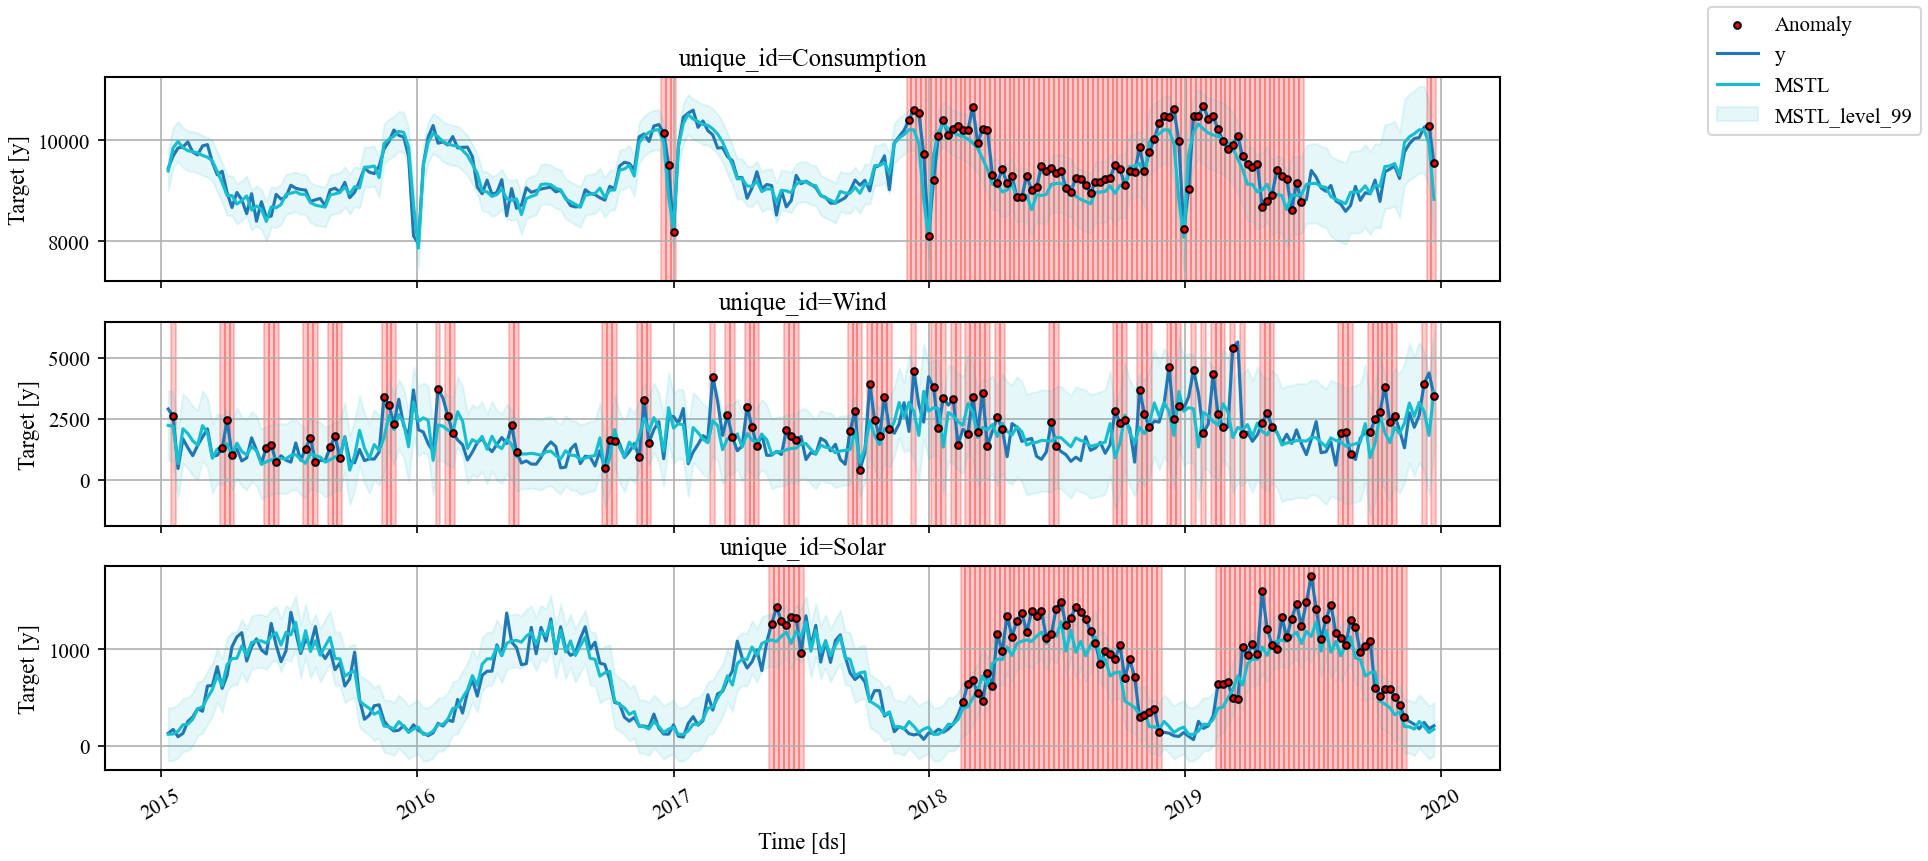

In [36]:
# 3. Смены режимов
plot_series_v2(forecasts_df=res_df, level=levels, models=['MSTL'],
               anomalies_df=transitions_df,
               marker_size=10, anomaly_width='1w')